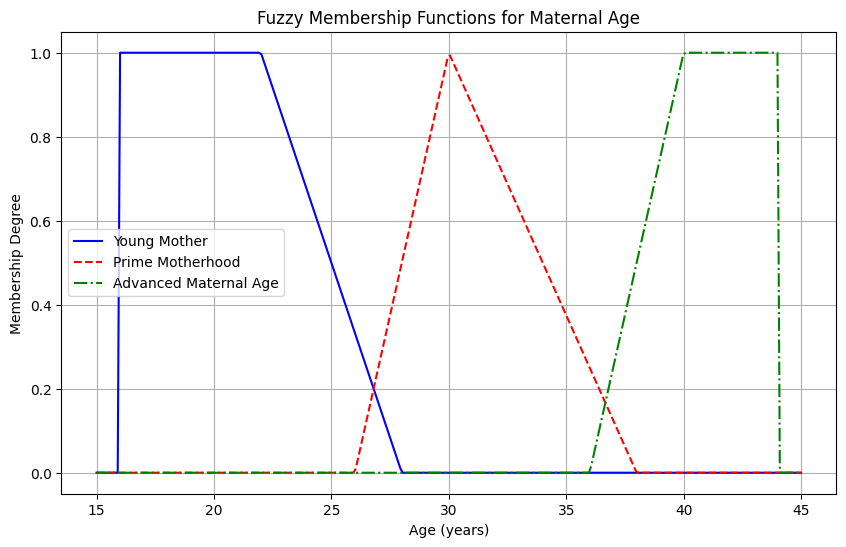

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Membership function definitions
def trapezoidal_mf(x, a, b, c, d):
    return np.maximum(np.minimum(np.minimum((x-a)/(b-a+1e-6), 1), (d-x)/(d-c+1e-6)), 0)

def triangular_mf(x, a, b, c):
    return np.maximum(np.minimum((x-a)/(b-a+1e-6), (c-x)/(c-b+1e-6)), 0)

# Parameters
young_mother_params = [16, 16, 22, 28]
prime_mother_params = [26, 30, 38]
advanced_age_params = [36, 40, 44, 44]

# X-axis range
x = np.linspace(15, 45, 300)

# Compute membership values
young_mother_mf = trapezoidal_mf(x, *young_mother_params)
prime_mother_mf = triangular_mf(x, *prime_mother_params)
advanced_age_mf = trapezoidal_mf(x, *advanced_age_params)

# Plotting
plt.figure(figsize=(10,6))
plt.plot(x, young_mother_mf, 'b-', label='Young Mother')  # solid line
plt.plot(x, prime_mother_mf, 'r--', label='Prime Motherhood')  # dashed line
plt.plot(x, advanced_age_mf, 'g-.', label='Advanced Maternal Age')  # dash-dot line

plt.title('Fuzzy Membership Functions for Maternal Age')
plt.xlabel('Age (years)')
plt.ylabel('Membership Degree')
plt.legend()
plt.grid(True)
plt.show()

C:\Users\MyMachine\AppData\Local\Temp\ipykernel_16524\2723725396.py:78: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('tab10')


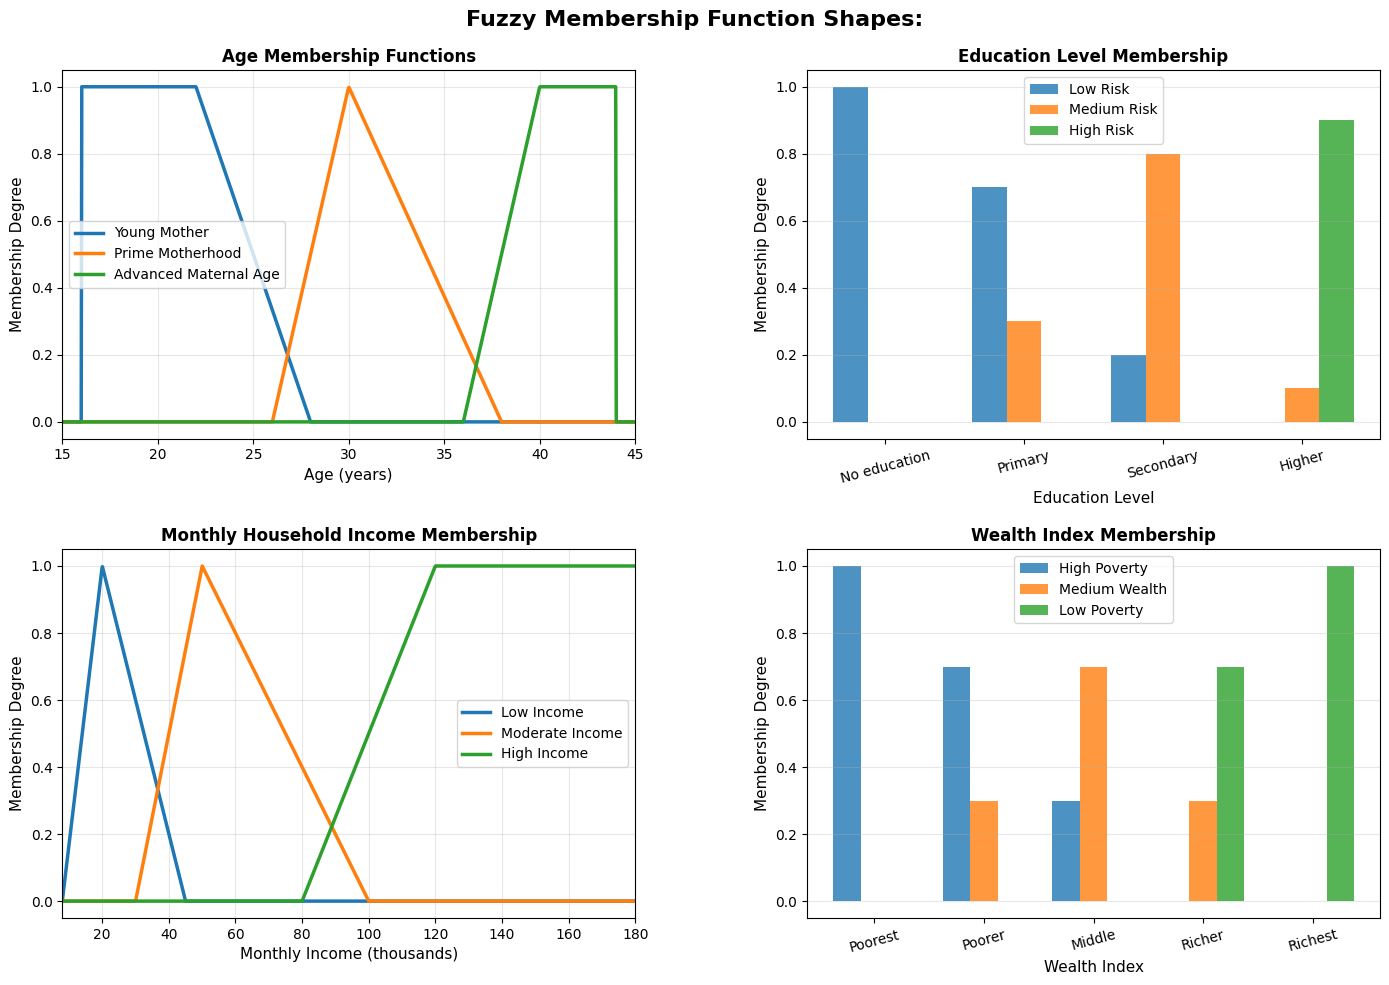

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap

# ============================
# DEFINE ALL FUZZY SET PARAMETERS
# ============================

# 1. Age parameters
young_mother_params = [16, 16, 22, 28]
prime_mother_params = [26, 30, 38]
advanced_age_params = [36, 40, 44, 44]

# 2. Education Level fuzzy map
fuzzy_map_edu = {
    'No education':       {'mu_edu_low_risk': 1.0, 'mu_edu_medium_risk': 0.0, 'mu_edu_high_risk': 0.0},
    'Primary':            {'mu_edu_low_risk': 0.7, 'mu_edu_medium_risk': 0.3, 'mu_edu_high_risk': 0.0},
    'Secondary':          {'mu_edu_low_risk': 0.2, 'mu_edu_medium_risk': 0.8, 'mu_edu_high_risk': 0.0},
    'Higher':             {'mu_edu_low_risk': 0.0, 'mu_edu_medium_risk': 0.1, 'mu_edu_high_risk': 0.9},
}

# 3. Monthly household income parameters
MIN_INCOME = 8000.0
MAX_INCOME = 180000.0
low_inc_params = [MIN_INCOME, 20000, 20000, 45000] 
mod_inc_params = [30000, 50000, 100000]
high_inc_params = [80000, 120000, MAX_INCOME, MAX_INCOME]

# 4. Wealth Index fuzzy map
fuzzy_map_wealth = {
    'Poorest':  {'mu_wealth_high_poverty': 1.0, 'mu_wealth_medium_wealth': 0.0, 'mu_wealth_low_poverty': 0.0},
    'Poorer':   {'mu_wealth_high_poverty': 0.7, 'mu_wealth_medium_wealth': 0.3, 'mu_wealth_low_poverty': 0.0},
    'Middle':   {'mu_wealth_high_poverty': 0.3, 'mu_wealth_medium_wealth': 0.7, 'mu_wealth_low_poverty': 0.0},
    'Richer':   {'mu_wealth_high_poverty': 0.0, 'mu_wealth_medium_wealth': 0.3, 'mu_wealth_low_poverty': 0.7},
    'Richest':  {'mu_wealth_high_poverty': 0.0, 'mu_wealth_medium_wealth': 0.0, 'mu_wealth_low_poverty': 1.0},
}

# ============================
# DEFINE MEMBERSHIP FUNCTIONS
# ============================

def left_open_trapezoidal(x, a, b, c, d):
    """Left-open trapezoidal membership function"""
    y = np.zeros_like(x, dtype=float)
    y[(x <= b) & (x > a)] = (x[(x <= b) & (x > a)] - a) / (b - a)
    y[(x > b) & (x <= c)] = 1.0
    y[(x > c) & (x <= d)] = (d - x[(x > c) & (x <= d)]) / (d - c)
    return y

def triangular(x, a, b, c):
    """Triangular membership function"""
    y = np.zeros_like(x, dtype=float)
    y[(x >= a) & (x <= b)] = (x[(x >= a) & (x <= b)] - a) / (b - a)
    y[(x > b) & (x <= c)] = (c - x[(x > b) & (x <= c)]) / (c - b)
    return y

def right_open_trapezoidal(x, a, b, c, d):
    """Right-open trapezoidal membership function"""
    y = np.zeros_like(x, dtype=float)
    y[(x >= a) & (x < b)] = (x[(x >= a) & (x < b)] - a) / (b - a)
    y[(x >= b) & (x <= c)] = 1.0
    y[(x > c) & (x <= d)] = 1.0
    return y

def trapezoidal(x, a, b, c, d):
    """Regular trapezoidal membership function"""
    y = np.zeros_like(x, dtype=float)
    y[(x >= a) & (x < b)] = (x[(x >= a) & (x < b)] - a) / (b - a)
    y[(x >= b) & (x <= c)] = 1.0
    y[(x > c) & (x <= d)] = (d - x[(x > c) & (x <= d)]) / (d - c)
    return y

# ============================
# CREATE THE PLOT
# ============================

# Define color scheme
cmap = get_cmap('tab10')
colors = [cmap(i) for i in range(10)]

# Create figure with 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Fuzzy Membership Function Shapes:', fontsize=16, fontweight='bold')

# ============================
# Subplot 1: Age
# ============================
ax1 = axes[0, 0]

# Generate age range
age_range = np.linspace(15, 45, 1000)

# Calculate membership values
young_mother_membership = left_open_trapezoidal(
    age_range, 
    young_mother_params[0], 
    young_mother_params[1], 
    young_mother_params[2], 
    young_mother_params[3]
)

prime_mother_membership = triangular(
    age_range, 
    prime_mother_params[0], 
    prime_mother_params[1], 
    prime_mother_params[2]
)

advanced_age_membership = right_open_trapezoidal(
    age_range, 
    advanced_age_params[0], 
    advanced_age_params[1], 
    advanced_age_params[2], 
    advanced_age_params[3]
)

# Plot age membership functions
ax1.plot(age_range, young_mother_membership, 
         label='Young Mother', linewidth=2.5, color=colors[0])
ax1.plot(age_range, prime_mother_membership, 
         label='Prime Motherhood', linewidth=2.5, color=colors[1])
ax1.plot(age_range, advanced_age_membership, 
         label='Advanced Maternal Age', linewidth=2.5, color=colors[2])

ax1.set_xlabel('Age (years)', fontsize=11)
ax1.set_ylabel('Membership Degree', fontsize=11)
ax1.set_title('Age Membership Functions', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='best')
ax1.set_xlim([15, 45])
ax1.set_ylim([-0.05, 1.05])

# ============================
# Subplot 2: Education Level (Discrete)
# ============================
ax2 = axes[0, 1]

# Education categories
edu_categories = list(fuzzy_map_edu.keys())
x_positions = np.arange(len(edu_categories))

# Prepare data for plotting
low_risk = []
medium_risk = []
high_risk = []

for category in edu_categories:
    low_risk.append(fuzzy_map_edu[category]['mu_edu_low_risk'])
    medium_risk.append(fuzzy_map_edu[category]['mu_edu_medium_risk'])
    high_risk.append(fuzzy_map_edu[category]['mu_edu_high_risk'])

# Width of each bar
width = 0.25

# Plot bars
ax2.bar(x_positions - width, low_risk, width, 
        label='Low Risk', color=colors[0], alpha=0.8)
ax2.bar(x_positions, medium_risk, width, 
        label='Medium Risk', color=colors[1], alpha=0.8)
ax2.bar(x_positions + width, high_risk, width, 
        label='High Risk', color=colors[2], alpha=0.8)

ax2.set_xlabel('Education Level', fontsize=11)
ax2.set_ylabel('Membership Degree', fontsize=11)
ax2.set_title('Education Level Membership', fontsize=12, fontweight='bold')
ax2.set_xticks(x_positions)
ax2.set_xticklabels(edu_categories, rotation=15)
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_ylim([-0.05, 1.05])

# ============================
# Subplot 3: Monthly Household Income
# ============================
ax3 = axes[1, 0]

# Generate income range
income_range = np.linspace(MIN_INCOME, MAX_INCOME, 1000)

# Calculate membership values
low_inc_membership = trapezoidal(
    income_range, 
    low_inc_params[0], 
    low_inc_params[1], 
    low_inc_params[2], 
    low_inc_params[3]
)

mod_inc_membership = triangular(
    income_range, 
    mod_inc_params[0], 
    mod_inc_params[1], 
    mod_inc_params[2]
)

high_inc_membership = right_open_trapezoidal(
    income_range, 
    high_inc_params[0], 
    high_inc_params[1], 
    high_inc_params[2], 
    high_inc_params[3]
)

# Plot income membership functions
ax3.plot(income_range / 1000, low_inc_membership, 
         label='Low Income', linewidth=2.5, color=colors[0])
ax3.plot(income_range / 1000, mod_inc_membership, 
         label='Moderate Income', linewidth=2.5, color=colors[1])
ax3.plot(income_range / 1000, high_inc_membership, 
         label='High Income', linewidth=2.5, color=colors[2])

ax3.set_xlabel('Monthly Income (thousands)', fontsize=11)
ax3.set_ylabel('Membership Degree', fontsize=11)
ax3.set_title('Monthly Household Income Membership', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.legend(loc='best')
ax3.set_xlim([MIN_INCOME/1000, MAX_INCOME/1000])
ax3.set_ylim([-0.05, 1.05])

# ============================
# Subplot 4: Wealth Index (Discrete)
# ============================
ax4 = axes[1, 1]

# Wealth categories
wealth_categories = list(fuzzy_map_wealth.keys())
x_positions_wealth = np.arange(len(wealth_categories))

# Prepare data for plotting
high_poverty = []
medium_wealth = []
low_poverty = []

for category in wealth_categories:
    high_poverty.append(fuzzy_map_wealth[category]['mu_wealth_high_poverty'])
    medium_wealth.append(fuzzy_map_wealth[category]['mu_wealth_medium_wealth'])
    low_poverty.append(fuzzy_map_wealth[category]['mu_wealth_low_poverty'])

# Width of each bar
width = 0.25

# Plot bars
ax4.bar(x_positions_wealth - width, high_poverty, width, 
        label='High Poverty', color=colors[0], alpha=0.8)
ax4.bar(x_positions_wealth, medium_wealth, width, 
        label='Medium Wealth', color=colors[1], alpha=0.8)
ax4.bar(x_positions_wealth + width, low_poverty, width, 
        label='Low Poverty', color=colors[2], alpha=0.8)

ax4.set_xlabel('Wealth Index', fontsize=11)
ax4.set_ylabel('Membership Degree', fontsize=11)
ax4.set_title('Wealth Index Membership', fontsize=12, fontweight='bold')
ax4.set_xticks(x_positions_wealth)
ax4.set_xticklabels(wealth_categories, rotation=15)
ax4.legend(loc='best')
ax4.grid(True, alpha=0.3, axis='y')
ax4.set_ylim([-0.05, 1.05])

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(top=0.92, hspace=0.3, wspace=0.3)

# Show plot
plt.show()